In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import fbu
physical_devices = tf.config.list_physical_devices('GPU') 
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)
from methods import IBU, NPU, MADE

import tensorflow_probability as tfp
from matplotlib import gridspec

tfd = tfp.distributions
tfpl = tfp.layers
tfk = tf.keras
tfkl = tf.keras.layers
tfb = tfp.bijectors

In [2]:
# Visualization from Jay: https://github.com/qwerasd903/UnbinnedProfiledUnfolding/blob/main/UnbinnedProfiledUnfolding.ipynb

class comparison_plots_with_ratio:
    
    def __init__(self, xmin, xmax, nbins, xlabel=r"$T$", ratio_label="Data/Pred.", header="Physics Example", density=True, save_name=None, legend_corner="upper left"):
        
        self.xmin = xmin
        self.xmax = xmax
        self.nbins = nbins
        self.density = density
        self.save_name = save_name
        self.legend_corner = legend_corner
        self.nTt = None
        self.bTt = None
        self.nTs = []
        self.bTs = []
        self.argss = []
        
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3,1])
        
        self.ax0 = plt.subplot(gs[0])
        self.ax0.yaxis.set_ticks_position('both')
        self.ax0.xaxis.set_ticks_position('both')
        self.ax0.tick_params(direction="in", which="both")
        plt.xticks(fontsize=0)
        plt.yticks(fontsize=20)
        self.ax0.minorticks_on()
        
        plt.ylabel("Normalized to Unity" if self.density else "Events", fontsize=20)
        plt.xlim([xmin,xmax])
        plt.title(header,loc="right",fontsize=20, fontstyle="italic")
        
        self.ax1 = plt.subplot(gs[1])
        self.ax1.yaxis.set_ticks_position('both')
        self.ax1.xaxis.set_ticks_position('both')
        self.ax1.tick_params(direction="in",which="both")
        self.ax1.minorticks_on()
        
        plt.xlim([xmin,xmax])
        plt.locator_params(axis='x', nbins=6)
        plt.xlabel(xlabel,fontsize=20)
        plt.ylabel(ratio_label,fontsize=20)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=15)
        plt.axhline(y=1,linewidth=2, color='gray')   
        plt.ylim(0.5,1.5)
        
    def add_data(self, data, label, target=False, weights=None, histtype=None, color=None, ls=None, lw=None, alpha=None):
        args = {"label": label}
        if type(weights) != type(None): args["weights"] = weights
        if type(histtype) != type(None): args["histtype"] = histtype
        if type(color) != type(None): args["color"] = color
        if type(ls) != type(None): args["ls"] = ls
        if type(lw) != type(None): args["lw"] = lw
        if type(alpha) != type(None): args["alpha"] = alpha
        nT, bT, _ = self.ax0.hist(data, bins=np.linspace(self.xmin, self.xmax, self.nbins), density=self.density, **args)
        if target:
            self.nTt = nT
            self.bTt = bT
        else:
            self.nTs.append(nT)
            self.bTs.append(bT)
            self.argss.append(args)
        
    def plot_ratio(self):
        if type(self.nTt) == type(None):
            return
        for nT, bT, _args in zip(self.nTs, self.bTs, self.argss):
            args = {}
            if "color" in _args: args["color"] = _args["color"]
            if "ls" in _args: args["ls"] = _args["ls"]
            self.ax1.plot(0.5*(self.bTt[1:]+self.bTt[:-1]),self.nTt/(0.000001+nT), **args)
            
    def save(self):
        if type(self.save_name) == type(None):
            return
        os.makedirs("plot", exist_ok=True)
        if os.path.isfile(f"plot/{self.save_name}.pdf"):
            i = 0
            while os.path.isfile(f"plot/{self.save_name}_{i}.pdf"):
                i += 1
            self.save_name = f"{self.save_name}_{i}"
        plt.savefig(f"plot/{self.save_name}.pdf", bbox_inches='tight')
    
    def show(self):
        self.plot_ratio()
        self.ax0.locator_params(axis='y', nbins=6)
        self.ax0.legend(frameon=False,fontsize=20, loc=self.legend_corner)
        self.save()
        plt.show()
        plt.clf()

In [7]:
samples = [
            "./phys/processed_madgraph_2j_1.0_1000000.npz", # MC
            "./phys/processed_madgraph_2j_1.2_1000000.npz", # nuisance = 1.2, "worst resolution"
            "./phys/processed_madgraph_2j_syst_1000000.npz", # uniform nuisance 0.5~1.5
            "./phys/processed_powheg_2j_1.2_200000.npz", # 'data'
]

In [8]:
madgraph_0 = np.load("./phys/processed_madgraph_2j_1.0_1000000.npz")
data = np.load("./phys/processed_powheg_2j_1.2_200000.npz")
print(madgraph_0.files)

nEvents = min(len(madgraph_0["T_Ptyy"]),len(data["T_Ptyy"]))
print(f"Restrict to {nEvents} events.")

T_sim = madgraph_0["T_Ptyy"][:nEvents].reshape(-1, 1)
R_sim = madgraph_0["R_Ptyy"][:nEvents].reshape(-1, 1)
R_myy_sim = madgraph_0["R_myy"][:nEvents].reshape(-1, 1)
             
T_data = data["T_Ptyy"][:nEvents].reshape(-1, 1)
R_data = data["R_Ptyy"][:nEvents].reshape(-1, 1)
R_myy_data = data["R_myy"][:nEvents].reshape(-1, 1)

['T_Pt_1', 'T_Pt_2', 'R_Pt_1', 'R_Pt_2', 'T_Ptyy', 'R_Ptyy', 'R_myy']
Restrict to 92328 events.


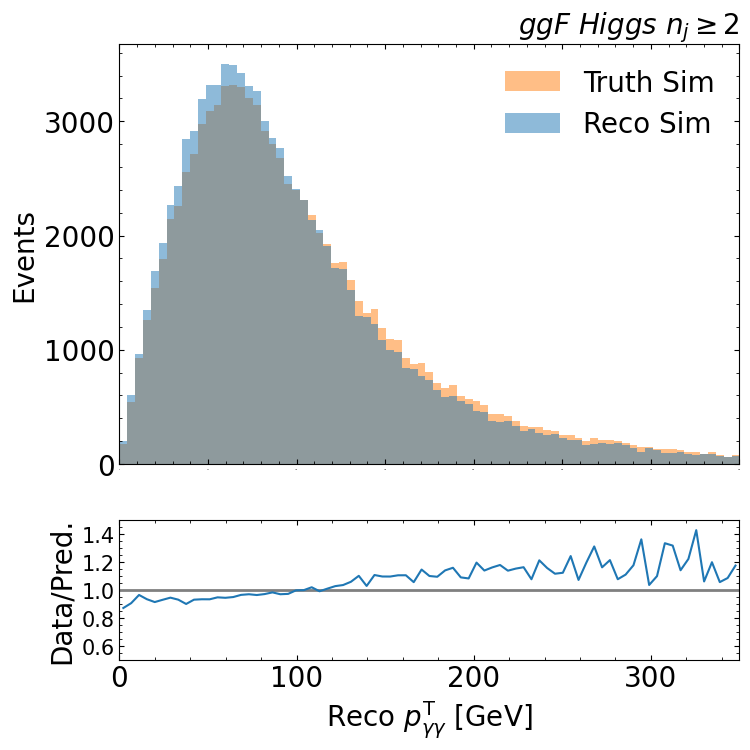

<Figure size 640x480 with 0 Axes>

In [9]:
cpwr = comparison_plots_with_ratio(0, 350, 80, xlabel=r"Reco $p^\mathrm{T}_{\gamma\gamma}$ [GeV]", density=False, legend_corner="upper right", header=r"ggF Higgs $n_j \geq 2$")
cpwr.add_data(T_sim, label="Truth Sim", target=True, alpha=0.5, color='tab:orange')
cpwr.add_data(R_sim, label="Reco Sim", alpha=0.5, color='tab:blue')
cpwr.show()

In [10]:
# rebinning optimized for diagFrac > 0.4
bins = np.linspace(0, 350, 10)
# bins = np.array([0., 40., 70., 90., 110., 150., 190., 240., 280., 300., 350.])
nbins = len(bins)-1

In [11]:
# Getting the response matrix for simulation
R = np.zeros([nbins,nbins])
NT, NR = len(madgraph_0["T_Ptyy"]), len(madgraph_0["R_Ptyy"])
# R,_,_ = np.histogram2d(R_sim, T_sim, bins=(bins, bins))

for i in range(1,nbins+1):
    T_sim_i = T_sim[np.digitize(T_sim, bins)==i]
    for j in range(1,nbins+1):
        R_sim_j = R_sim[(np.digitize(T_sim, bins)==i)&(np.digitize(R_sim, bins)==j)]
        # print( len(T_sim_i), len(R_sim_j))
        R[i-1,j-1] = len(R_sim_j)/len(T_sim_i)

R = R.T

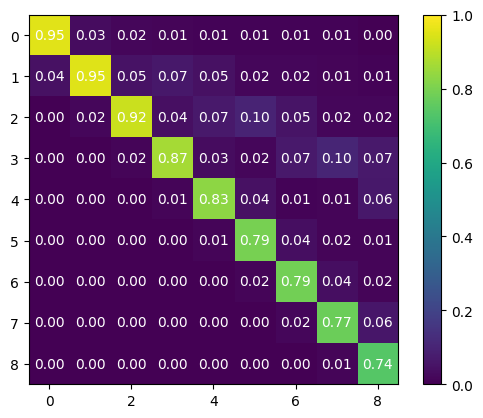

In [12]:
plt.imshow(R, vmin=0, vmax=1)#, origin='lower')
plt.colorbar()

for i in range(len(R)):
    for j in range(len(R)):
        text = plt.text(j, i, f"{R[i, j]:.2f}", ha="center", va="center", color="w")
        
plt.show()

In [13]:
# data
t = np.array([(np.digitize(T_data, bins)==i).sum() for i in range(1, nbins+1)])
m = np.array([(np.digitize(R_data, bins)==i).sum() for i in range(1, nbins+1)])

# prior (for IBU)
p = np.array([1./nbins for i in range(1, nbins+1)])

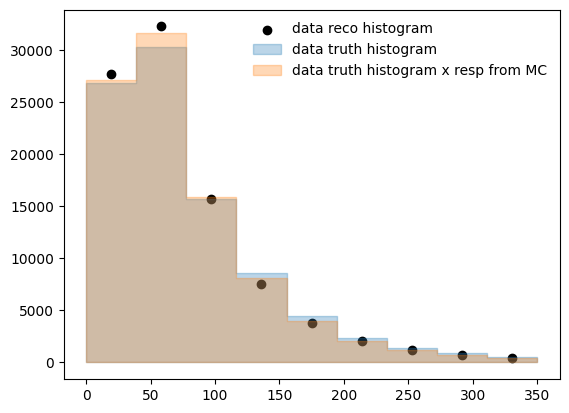

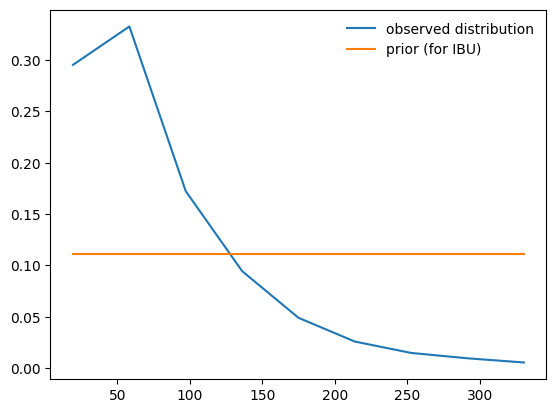

In [14]:
plt.scatter(0.5*(bins[1:]+bins[:-1]), m, color='black', label='data reco histogram')
plt.fill_between(bins, np.insert(t, len(t), np.array(t[-1])), step='post', alpha=0.3, color='tab:blue', label='data truth histogram')
plt.fill_between(bins, np.insert(R@t, len(R@t), np.array(np.matmul(R, t)[-1])), step='post', alpha=0.3, color='tab:orange', label='data truth histogram x resp from MC')
plt.legend(frameon=False, loc="upper right")
plt.show()
plt.clf()

plt.plot(0.5*(bins[1:]+bins[:-1]), t/t.sum(), label='observed distribution')
plt.plot(0.5*(bins[1:]+bins[:-1]), p, label='prior (for IBU)')
plt.legend(frameon=False, loc="upper right")
plt.show()

In [15]:
def MLE(model,ymes,ndim):
    x = tf.Variable(ndim*[1.0/ndim])
    loss = lambda: -model.log_prob(x, bijector_kwargs={'conditional_input': ymes})
    losses = tfp.math.minimize(loss,
                               num_steps=10000,
                               #convergence_criterion=(
                               #     tfp.optimizers.convergence_criteria.LossNotDecreasing(atol=0.001)),
                               trainable_variables=[x],
                               optimizer=tf.optimizers.Adam(learning_rate=0.001))
    return x

def MADE(data_shape, cond_shape):
    # Density estimation with MADE.
    made = tfb.AutoregressiveNetwork(params=2,
                                     hidden_units=[50,50,50], #To be changed when using bigger histograms
                                     event_shape=data_shape,
                                     activation='swish',
                                     conditional=True,
                                     conditional_event_shape=cond_shape,
                                    )
    distribution = tfd.TransformedDistribution(
        distribution=tfd.Sample(tfd.Normal(loc=0., scale=1.), sample_shape=[data_shape]),
        bijector=tfb.MaskedAutoregressiveFlow(made))

    # Construct and fit model.
    x_ = tfkl.Input(shape=(data_shape,), dtype=tf.float32)
    c_ = tfkl.Input(shape=(cond_shape,), dtype=tf.float32)
    log_prob_ = distribution.log_prob(x_, bijector_kwargs={'conditional_input': c_})
    model = tfk.Model([x_,c_], log_prob_)

    model.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-4),loss=lambda _, log_prob: -log_prob)
    return model, distribution

def NPU(ymes,Rin,N):
    #Inputs: 
    # ymes: Measured data provided in a histogram with N bins (N,)
    # Rin: Detector resolution matrix. First coordinate is the measured value and second coordinate is the truth level. (M,M)
    # N: Total number of observations
    #Returns samples from p(true|measured).  Would normally want the mode over true, which is equivalent to the MLE given p(true) is uniform.

    M = 1000000 # a big number - should make bigger later

    ts = np.random.uniform(0,1,(M,len(ymes)) ) # M values with len(ymes) bins
    ts=N*ts/np.sum(ts,-1,keepdims=True)
    print(np.sum(ts,-1))

    ms = []
    for j in range(len(ts)):
        if j % 100000 == 0: print(f"{j}/{len(ts)}")
        m_hold = [np.random.poisson(ts[j][i]) for i in range(len(ts[j]))] #stat fluctuations
        m_holds = np.random.multinomial(m_hold[0],Rin[:,0])
        for i in range(1, len(ts[j])):
            m_holds += np.random.multinomial(m_hold[i],Rin[:,i])
        ms += [m_holds]
        pass
    ts = np.array(ts)
    ms = np.array(ms)

    n = len(ts)
    x = ms #conditional feature
    y = ts #learn p(y|x)
    nx = N
    ny = N

    #Normalize the total number of events to make the NF easier to train
    x = x/float(nx)
    y = y/float(ny)

    model,dist = MADE(y.shape[1],x.shape[1])
    # Fit.
    batch_size = 10000
    myhistory = model.fit([y,x],
                          y=np.zeros((len(x),0), dtype=np.float32), #dummy labels
                          batch_size=batch_size,
                          epochs=800,
                          verbose = 1)

    plt.plot(myhistory.history['loss'][10:-1])
    plt.xlabel("epochs")
    plt.ylabel("loss")

    # mle = MLE(dist,ymes/float(nx),y.shape[-1])
    # print(mle)
    nsample = 1000
    mle = MLE(dist,ymes/float(nx),y.shape[-1]).numpy()
    output = dist.sample(nsample, bijector_kwargs={'conditional_input': np.tile(ymes/float(nx),nsample).reshape([nsample,len(ymes)])}).numpy()
    return output*ny,mle*ny

91356
[91356. 91356. 91356. ... 91356. 91356. 91356.]
0/1000000
100000/1000000
200000/1000000
300000/1000000
400000/1000000
500000/1000000
600000/1000000
700000/1000000
800000/1000000
900000/1000000


2024-05-02 13:49:31.069848: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-02 13:49:31.794085: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 36242 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:41:00.0, compute capability: 8.0


Epoch 1/800
 36/100 [=========>....................] - ETA: 0s - loss: 8.0160 

2024-05-02 13:49:33.984532: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


100/100 [==============================] - 2s 3ms/step - loss: 7.8313
Epoch 2/800
100/100 [==============================] - 0s 3ms/step - loss: 7.1619
Epoch 3/800
100/100 [==============================] - 0s 3ms/step - loss: 6.1650
Epoch 4/800
100/100 [==============================] - 0s 3ms/step - loss: 4.5209
Epoch 5/800
100/100 [==============================] - 0s 3ms/step - loss: 1.8097
Epoch 6/800
100/100 [==============================] - 0s 3ms/step - loss: -1.3448
Epoch 7/800
100/100 [==============================] - 0s 3ms/step - loss: -3.5869
Epoch 8/800
100/100 [==============================] - 0s 3ms/step - loss: -6.3479
Epoch 9/800
100/100 [==============================] - 0s 3ms/step - loss: -10.3345
Epoch 10/800
100/100 [==============================] - 0s 3ms/step - loss: -12.1835
Epoch 11/800
100/100 [==============================] - 0s 3ms/step - loss: -13.0625
Epoch 12/800
100/100 [==============================] - 0s 3ms/step - loss: -13.5439
Epoch 13/800
1

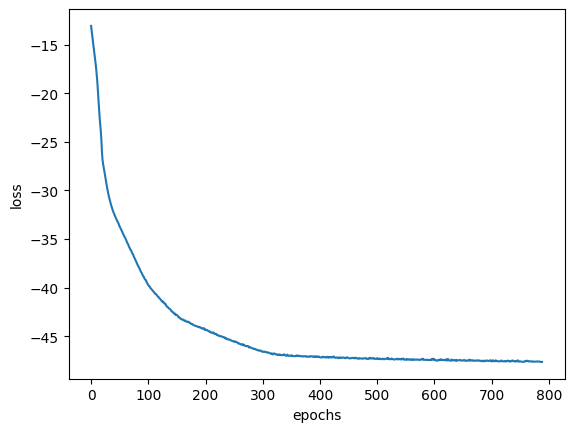

In [16]:
N = m.sum()
print(N)

npu,mle = NPU(m,R,N)

In [17]:
def IBU(ymes,t0,Rin,n):
    #This is the iterative Bayesian unfolding method.
    #Rin is a matrix where the first coordinate is the measured value and the second coordinate is the true value.
    #n is the number of iterations.

    tn = t0
    for i in range(n):
        Rjitni = [np.array(Rin[:][i])*tn[i] for i in range(len(tn))]
        Pm_given_t = Rjitni / np.matmul(Rin,tn)
        tn = np.dot(Pm_given_t,ymes)
        pass
    return tn

ibu = IBU(m,p,R,len(m))

In [19]:
fbu = fbu.PyFBU()
fbu.data = m
fbu.response = R
fbu.lower = list(np.zeros(nbins))
fbu.upper = list(800000 * np.ones(nbins))
fbu.run()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...


None


Sequential sampling (2 chains in 1 job)
NUTS: [truth8, truth7, truth6, truth5, truth4, truth3, truth2, truth1, truth0]
100%|██████████| 11000/11000 [00:10<00:00, 1065.24it/s]


Elapsed 0:01:57 (187.00 samples/second)


In [21]:
trace = fbu.trace
print(trace)

fbu_result, fbu_sigma = [], []
for i in range(nbins):
    fbu_result.append(np.mean(trace[i]))
    fbu_sigma.append(np.std(trace[i]))

[array([27189.17408579, 27503.62383856, 27428.83719829, ...,
       26880.6993762 , 26895.93365513, 27621.13094547]), array([32677.74967894, 32423.48763777, 32243.17386219, ...,
       32335.1932617 , 32535.49489873, 32497.25212593]), array([14156.27013218, 13743.03009857, 13975.016115  , ...,
       13976.58995338, 14054.51168621, 13972.23262478]), array([4122.1475484 , 4218.12297021, 4312.06156171, ..., 4112.00557987,
       4134.40306254, 4124.78399752]), array([757.59783149, 930.77661141, 949.6024484 , ..., 872.370422  ,
       882.78661102, 725.35205166]), array([9.6180186 , 2.46031379, 5.83862823, ..., 1.27126138, 0.89182737,
       1.60468158]), array([3.64131341, 2.97667252, 8.16233803, ..., 0.24223935, 0.17843761,
       0.30811093]), array([1.48674334, 3.10752094, 1.65360413, ..., 0.00658271, 0.04275652,
       0.53923756]), array([1.86941271, 0.82509367, 1.94782989, ..., 3.13467378, 5.09322499,
       0.90561569])]


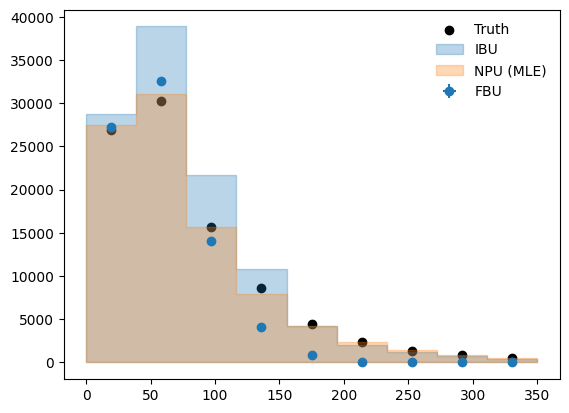

<Figure size 640x480 with 0 Axes>

In [22]:
# plt.scatter(list(0.5*(bins[1:]+bins[:-1]))*1000,npu.reshape(-1), marker='*', label="NPU",s=40)
# train stat = 10000
#plt.errorbar(0.5*(bins[1:]+bins[:-1]), npu.mean(axis=0), xerr=0, yerr=npu.std(axis=0), label='NPU', marker='o', linestyle='None')
plt.scatter(0.5*(bins[1:]+bins[:-1]), t, color='black', label='Truth')
plt.errorbar(0.5*(bins[1:]+bins[:-1]), fbu_result, xerr=0, yerr=fbu_sigma, label='FBU', marker='o', linestyle='None')
plt.fill_between(bins, np.insert(ibu, len(ibu), np.array(ibu[-1])), step='post', alpha=0.3, color='tab:blue', label='IBU')
plt.fill_between(bins, np.insert(mle, len(mle), np.array(mle[-1])), step='post', alpha=0.3, color='tab:orange', label='NPU (MLE)')
plt.legend(frameon=False, loc="upper right")
plt.show()
plt.clf()

In [ ]:
!python -m pip install corner

In [ ]:
import corner

In [ ]:
np.savez_compressed("npu_gaussian_10000000.npz", **{"bins": bins, "npu": npu, "t": t, "ibu": ibu, "mle": mle})

In [ ]:
aaa=np.load("npu_gaussian_10000000.npz")

In [ ]:
list(aaa.keys())

In [ ]:
figure = corner.corner(
    npu,
#     labels=[
#         r"Bin Index",
#         r"Bin Index",
#         r"$\log \alpha$",
#         r"$\Gamma \, [\mathrm{parsec}]$",
#     ],
#     quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
)